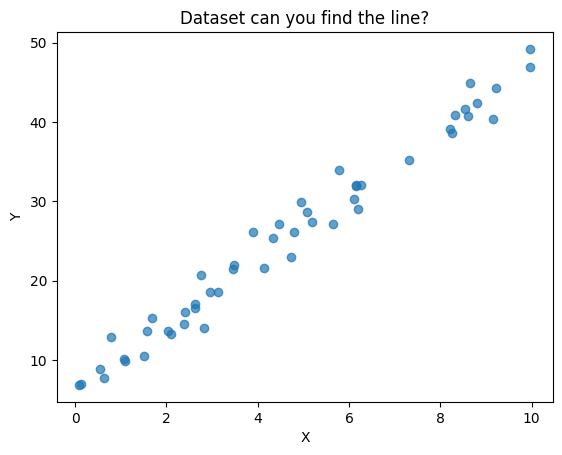

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import axis

X = np.random.uniform(0, 10, size=50)
noise = np.random.randn(50) * 2
y = X * 4 + 7 + noise

plt.scatter(X, y, alpha=.7)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Dataset can you find the line?")
plt.show()

In [2]:
def predict(X, w, b):
    return w * X + b

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

w = 0.0
b = 0.0

print(f"Initial prediction for X=5: {predict(5, w, b)}")
print(f"initial loss for X=5: {mse_loss(y, predict(5, w, b)):.2f}")

Initial prediction for X=5: 0.0
initial loss for X=5: 782.00


In [3]:
def compute_gradient(X, y, w, b):
    n = len(X)
    y_pred = predict(X, w, b)
    error = y - y_pred

    dw = (-2 / n) * np.sum(X * error)
    db = (-2 / n) * np.sum(error)

    return dw, db

In [5]:
def numerical_gradient(X, y, w, b, param='w', eps=1e-5):
    if param == 'w':
        loss_plus = mse_loss(y, predict(X, w + eps, b))
        loss_minus = mse_loss(y, predict(X, w - eps, b))
    else:
        loss_plus = mse_loss(y, predict(X, w, b + eps))
        loss_minus = mse_loss(y, predict(X, w, b - eps))
    return (loss_plus - loss_minus) / (2 * eps)

dw_analytical, db_analytical = compute_gradient(X, y, w, b)
dw_numerical = numerical_gradient(X, y, w, b, 'w')
db_numerical = numerical_gradient(X, y, w, b, 'b')

print(f"dw - analytical: {dw_analytical:.6f}, numerical: {dw_numerical:.6f}")
print(f"db - analytical: {db_analytical:.6f}, numerical: {db_numerical:.6f}")

dw - analytical: -301.189921, numerical: -301.189921
db - analytical: -50.624749, numerical: -50.624749


In [11]:
w = 0.0
b = 0.0
lr = 0.01
epochs = 20000

history = []

for epoch in range(epochs):
    dw, db = compute_gradient(X, y, w, b)
    w = w - lr * dw
    b = b - lr * db

    loss = mse_loss(y, predict(X, w, b))
    history.append(loss)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | loss={loss:.4f} | w={w:.4f} | b={b:.4f}")

print(f"\nFinal: w={w:.4f}, b={b:.4f}")

Epoch   0 | loss=131.7068 | w=3.0119 | b=0.5062
Epoch  20 | loss=10.3265 | w=4.8837 | b=1.3968
Epoch  40 | loss=8.9383 | w=4.8016 | b=1.9177
Epoch  60 | loss=7.8226 | w=4.7279 | b=2.3847
Epoch  80 | loss=6.9259 | w=4.6619 | b=2.8034
Epoch 100 | loss=6.2052 | w=4.6028 | b=3.1788
Epoch 120 | loss=5.6259 | w=4.5497 | b=3.5153
Epoch 140 | loss=5.1604 | w=4.5022 | b=3.8170
Epoch 160 | loss=4.7862 | w=4.4596 | b=4.0874
Epoch 180 | loss=4.4855 | w=4.4213 | b=4.3299
Epoch 200 | loss=4.2437 | w=4.3871 | b=4.5473
Epoch 220 | loss=4.0495 | w=4.3564 | b=4.7422
Epoch 240 | loss=3.8933 | w=4.3288 | b=4.9169
Epoch 260 | loss=3.7679 | w=4.3041 | b=5.0735
Epoch 280 | loss=3.6670 | w=4.2820 | b=5.2139
Epoch 300 | loss=3.5859 | w=4.2622 | b=5.3398
Epoch 320 | loss=3.5208 | w=4.2444 | b=5.4526
Epoch 340 | loss=3.4684 | w=4.2284 | b=5.5538
Epoch 360 | loss=3.4263 | w=4.2141 | b=5.6445
Epoch 380 | loss=3.3925 | w=4.2013 | b=5.7258
Epoch 400 | loss=3.3653 | w=4.1898 | b=5.7987
Epoch 420 | loss=3.3435 | w=4.1

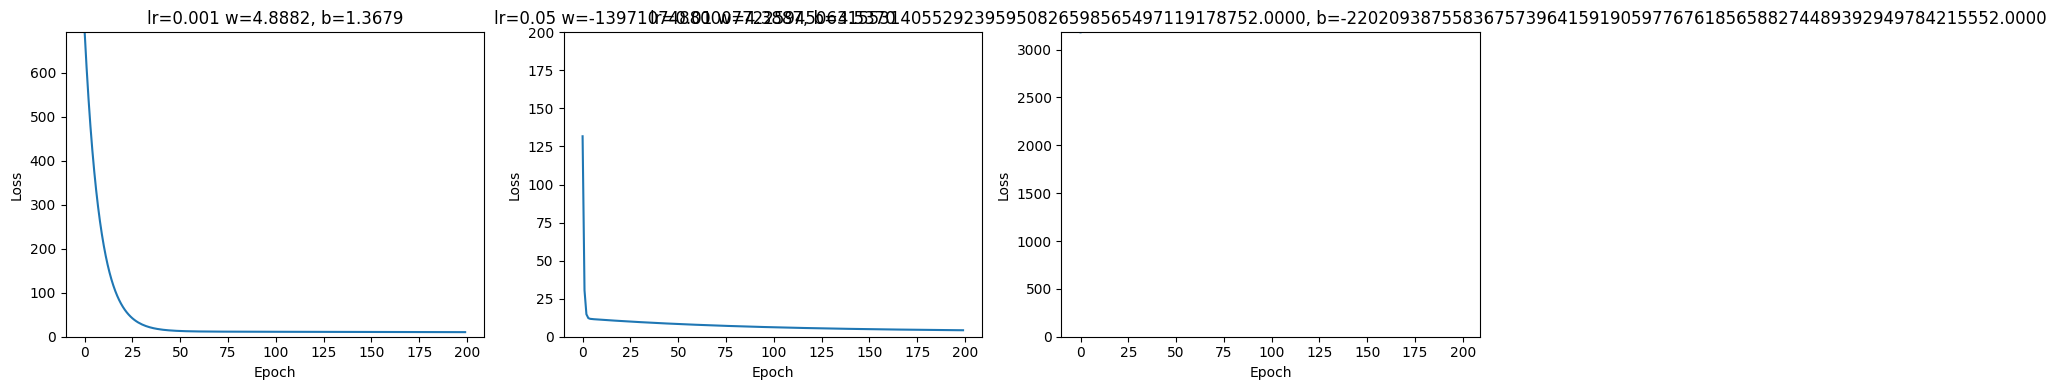

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, lr_test in enumerate([0.001, 0.01, 0.05]):
    w_t, b_t = 0.0, 0.0
    hist = []
    for _ in range(200):
        dw, db = compute_gradient(X, y, w_t, b_t)
        w_t -= lr_test * dw
        b_t -= lr_test * db
        hist.append(mse_loss(y, predict(X, w_t, b_t)))

    axes[i].plot(hist)
    axes[i].set_title(f"lr={lr_test} w={w_t:.4f}, b={b_t:.4f}")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Loss")
    axes[i].set_ylim([0, max(hist[0], 200)])

plt.tight_layout()
plt.show()

In [10]:
X_matrix = np.column_stack([X, np.ones(len(X))])

theta = np.linalg.inv(X_matrix.T @ X_matrix) @ X_matrix.T @ y

print(f"Normal Equation: w={theta[0]:.4f}, b={theta[1]:.4f}")
print(f"Gradient Descent: w={w:.4f}, b={b:.4f}")

Normal Equation: w=4.0903, b=6.4302
Gradient Descent: w=4.0903, b=6.4301
